## 1. Setup Environment

Import the required libraries, configure random seeds for reproducibility, and detect GPU availability.

In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import torch
import xgboost as xgb

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Detect GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Load Dataset

Load the dataset from the specified path or manual upload. If the file is not found, we generate a small dummy dataset to keep the notebook fully runnable. Then, we automatically identify the fraud target column and convert it to a binary format (0/1).

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/vehicle-claim-fraud-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehicle-claim-fraud-detection' dataset.
Path to dataset files: /kaggle/input/vehicle-claim-fraud-detection


In [6]:
dir_path = path

# Locate the CSV file inside the downloaded directory
file_path = None
if os.path.exists(dir_path) and os.path.isdir(dir_path):
    for file in os.listdir(dir_path):
        if file.endswith('.csv'):
            file_path = os.path.join(dir_path, file)
            break

if file_path is None:
    raise FileNotFoundError(f"No CSV file found in {dir_path}. Please check if the download was successful.")

df = pd.read_csv(file_path)
print(f"Successfully loaded dataset from: {file_path}")

print(f"\nDataset Shape: {df.shape}")
print("Columns:", df.columns.tolist())
display(df.head())

# Target Column Detection
target_candidates = [col for col in df.columns if 'fraud' in col.lower()]
target_col = target_candidates[0] if target_candidates else df.columns[-1]
print(f"\nDetected Target Column: '{target_col}'")

# Convert to binary
if df[target_col].dtype == 'object':
    print(f"Unique target values before conversion: {df[target_col].unique()}")
    # Mapping common positive/fraud indicators to 1, rest to 0
    df[target_col] = df[target_col].apply(lambda x: 1 if str(x).lower() in ['yes', 'y', '1', 'true', 'fraud'] else 0)

print("\nTarget distribution after binary conversion (1 = Fraud, 0 = Non-Fraud):")
print(df[target_col].value_counts())


Successfully loaded dataset from: /kaggle/input/vehicle-claim-fraud-detection/fraud_oracle.csv

Dataset Shape: (15420, 33)
Columns: ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision



Detected Target Column: 'FraudFound_P'

Target distribution after binary conversion (1 = Fraud, 0 = Non-Fraud):
FraudFound_P
0    14497
1      923
Name: count, dtype: int64


In [7]:
pd.set_option('display.max_columns', None)
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [8]:
# Let's first look at the unique values and their frequencies
print("Unique VehiclePrice categories:")
price_counts = df['VehiclePrice'].value_counts()
print(price_counts)

# We can extract the first number from the string to help sort them logically
import re

def get_starting_price(val):
    # Handle 'less than' specifically so it sorts first
    if 'less' in str(val).lower():
        return 0
    # Find all sequences of digits
    numbers = re.findall(r'\d+', str(val))
    if numbers:
        return int(numbers[0])
    return 0

# Create a sorted list of the unique categories based on their numerical value
unique_prices = df['VehiclePrice'].unique()
sorted_prices = sorted(unique_prices, key=get_starting_price)

# Create a mapping dictionary (e.g., lowest price range = 1, next = 2, etc.)
price_mapping = {price: i+1 for i, price in enumerate(sorted_prices)}
print(f"\nCreated mapping: {price_mapping}")

# Apply the mapping to a new column (or overwrite the existing one)
df['VehiclePrice_Mapped'] = df['VehiclePrice'].map(price_mapping)

# Display the result to verify
display(df[['VehiclePrice', 'VehiclePrice_Mapped']].head(10))


Unique VehiclePrice categories:
VehiclePrice
20000 to 29000     8079
30000 to 39000     3533
more than 69000    2164
less than 20000    1096
40000 to 59000      461
60000 to 69000       87
Name: count, dtype: int64

Created mapping: {'less than 20000': 1, '20000 to 29000': 2, '30000 to 39000': 3, '40000 to 59000': 4, '60000 to 69000': 5, 'more than 69000': 6}


,VehiclePrice,VehiclePrice_Mapped
0,more than 69000,6
1,more than 69000,6
2,more than 69000,6
3,20000 to 29000,2
4,more than 69000,6
5,more than 69000,6
6,more than 69000,6
7,more than 69000,6
8,more than 69000,6
9,more than 69000,6


In [9]:
import re

# 1. Make AgeOfVehicle numeric by extracting the first number
# (e.g., '3 years' -> 3, 'more than 7' -> 7, 'new' -> 0)
def get_vehicle_age(val):
    if 'new' in str(val).lower():
        return 0
    nums = re.findall(r'\d+', str(val))
    if nums:
        return int(nums[0])
    return 0

df['AgeOfVehicle_Mapped'] = df['AgeOfVehicle'].apply(get_vehicle_age)

# 2. AgeOfPolicyHolder mapping (Ordinally mapped based on starting age)
def get_policy_holder_age(val):
    nums = re.findall(r'\d+', str(val))
    if nums:
        return int(nums[0])
    return 0

unique_ages = df['AgeOfPolicyHolder'].unique()
sorted_ages = sorted(unique_ages, key=get_policy_holder_age)
age_mapping = {age: i+1 for i, age in enumerate(sorted_ages)}
df['AgeOfPolicyHolder_Mapped'] = df['AgeOfPolicyHolder'].map(age_mapping)

# 3. Binary Encodings for PoliceReportFiled and WitnessPresent
# We also handle cases where it might already be 0/1 to avoid NaNs if run twice
df['PoliceReportFiled'] = df['PoliceReportFiled'].map({'No': 0, 'Yes': 1, 0: 0, 1: 1})
df['WitnessPresent'] = df['WitnessPresent'].map({'No': 0, 'Yes': 1, 0: 0, 1: 1})

# 4. PastNumberOfClaims: turn 'none' to '0'
df['PastNumberOfClaims'] = df['PastNumberOfClaims'].replace({'none': '0', 'None': '0'})

# Display the results
display(df[['AgeOfVehicle', 'AgeOfVehicle_Mapped',
            'AgeOfPolicyHolder', 'AgeOfPolicyHolder_Mapped',
            'PoliceReportFiled', 'WitnessPresent', 'PastNumberOfClaims']].head(10))


,AgeOfVehicle,AgeOfVehicle_Mapped,AgeOfPolicyHolder,AgeOfPolicyHolder_Mapped,PoliceReportFiled,WitnessPresent,PastNumberOfClaims
0,3 years,3,26 to 30,4,0,0,0
1,6 years,6,31 to 35,5,1,0,0
2,7 years,7,41 to 50,7,0,0,1
3,more than 7,7,51 to 65,8,1,0,1
4,5 years,5,31 to 35,5,0,0,0
5,5 years,5,21 to 25,3,0,0,0
6,7 years,7,36 to 40,6,0,0,1
7,new,0,16 to 17,1,0,0,1
8,6 years,6,31 to 35,5,0,1,0
9,more than 7,7,36 to 40,6,0,0,2 to 4


In [10]:
import re

def extract_first_number(val, zero_keywords=['no change', 'none']):
    val_str = str(val).lower()
    for kw in zero_keywords:
        if kw in val_str:
            return 0
    nums = re.findall(r'\d+', val_str)
    if nums:
        return int(nums[0])
    return 0

# 1. AddressChange_Claim ('no change' -> 0, '1 year' -> 1, '4 to 8 years' -> 4, etc.)
df['AddressChange_Claim_Mapped'] = df['AddressChange_Claim'].apply(lambda x: extract_first_number(x, ['no change']))

# 2. NumberOfCars ('1 vehicle' -> 1, '3 to 4' -> 3, etc.)
df['NumberOfCars_Mapped'] = df['NumberOfCars'].apply(lambda x: extract_first_number(x))

# 3. NumberOfSuppliments ('none' -> 0, 'more than 5' -> 5, etc.)
df['NumberOfSuppliments_Mapped'] = df['NumberOfSuppliments'].apply(lambda x: extract_first_number(x, ['none']))

# Display the results to verify
display(df[['AddressChange_Claim', 'AddressChange_Claim_Mapped',
            'NumberOfCars', 'NumberOfCars_Mapped',
            'NumberOfSuppliments', 'NumberOfSuppliments_Mapped']].head(10))


,AddressChange_Claim,AddressChange_Claim_Mapped,NumberOfCars,NumberOfCars_Mapped,NumberOfSuppliments,NumberOfSuppliments_Mapped
0,1 year,1,3 to 4,3,none,0
1,no change,0,1 vehicle,1,none,0
2,no change,0,1 vehicle,1,none,0
3,no change,0,1 vehicle,1,more than 5,5
4,no change,0,1 vehicle,1,none,0
5,no change,0,1 vehicle,1,3 to 5,3
6,no change,0,1 vehicle,1,1 to 2,1
7,no change,0,1 vehicle,1,none,0
8,no change,0,1 vehicle,1,3 to 5,3
9,no change,0,1 vehicle,1,3 to 5,3


## 3. Exploratory Data Analysis (EDA)

Examine missing values, view summary statistics, and visualize the distributions of the target label alongside a few numerical and categorical features.

Missing Values per Column:
No missing values detected.

Summary Statistics:


,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,PoliceReportFiled,WitnessPresent,Year,VehiclePrice_Mapped,AgeOfVehicle_Mapped,AgeOfPolicyHolder_Mapped,AddressChange_Claim_Mapped,NumberOfCars_Mapped,NumberOfSuppliments_Mapped
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,0.027756,0.005642,1994.866472,2.796109,6.323411,5.891894,0.214008,1.100584,1.807717
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.164279,0.074904,0.803313,1.443017,1.308801,1.395907,0.839542,0.400644,2.083398
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,0.000000,0.000000,1994.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,0.000000,0.000000,1994.000000,2.000000,6.000000,5.000000,0.000000,1.000000,0.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,0.000000,0.000000,1995.000000,2.000000,7.000000,6.000000,0.000000,1.000000,1.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,0.000000,0.000000,1996.000000,3.000000,7.000000,7.000000,0.000000,1.000000,5.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1.000000,1.000000,1996.000000,6.000000,7.000000,9.000000,6.000000,8.000000,5.000000


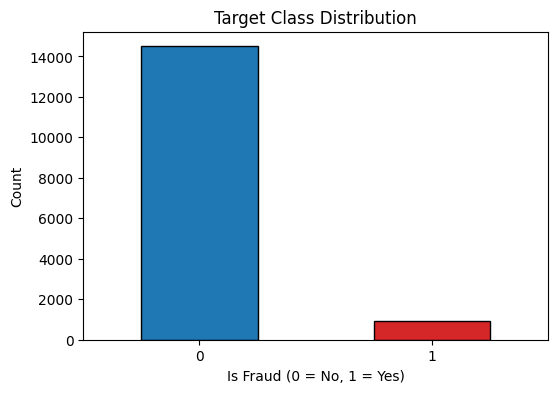

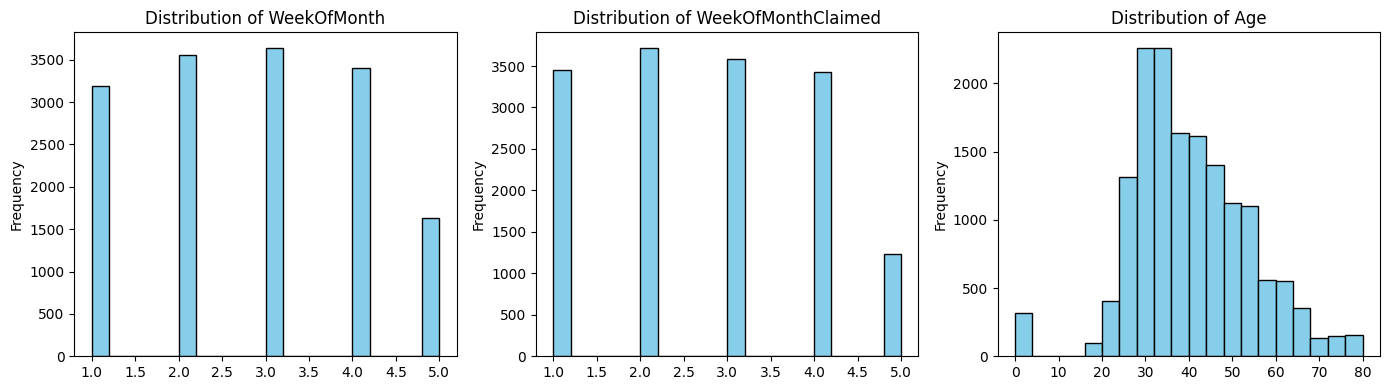

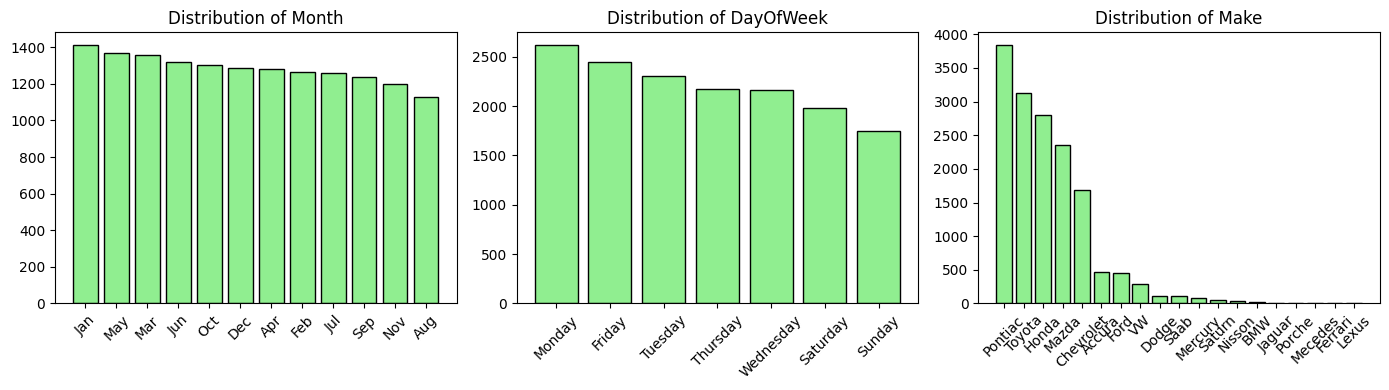

In [11]:
# 1. Missing Values
missing_vals = df.isnull().sum()
print("Missing Values per Column:")
print(missing_vals[missing_vals > 0] if missing_vals.any() else "No missing values detected.")

# 2. Summary Statistics
print("\nSummary Statistics:")
display(df.describe())

# 3. Plot Class Distribution
plt.figure(figsize=(6, 4))
df[target_col].value_counts().sort_index().plot(kind='bar', color=['#1f77b4', '#d62728'], edgecolor='black')
plt.title('Target Class Distribution')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Group columns by data type for feature plotting
num_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col, errors='ignore').tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# 4. Plot 2-3 Numerical Features
num_plot_cols = num_cols[:3]
if num_plot_cols:
    fig, axes = plt.subplots(1, len(num_plot_cols), figsize=(14, 4))
    if len(num_plot_cols) == 1: axes = [axes]
    for ax, col in zip(axes, num_plot_cols):
        ax.hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
        ax.set_title(f'Distribution of {col}')
        ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# 5. Plot 2-3 Categorical Features
cat_plot_cols = cat_cols[:3]
if cat_plot_cols:
    fig, axes = plt.subplots(1, len(cat_plot_cols), figsize=(14, 4))
    if len(cat_plot_cols) == 1: axes = [axes]
    for ax, col in zip(axes, cat_plot_cols):
        val_counts = df[col].value_counts()
        ax.bar(val_counts.index.astype(str), val_counts.values, color='lightgreen', edgecolor='black')
        ax.set_title(f'Distribution of {col}')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 4. Data Preprocessing & Split

In this section, we:
* Drop obvious ID columns like `policy_number`.
* Automatically detect categorical and numerical columns.
* Set up a scikit-learn `Pipeline` to impute missing values (median for numerical, most frequent for categorical).
* Apply OneHotEncoding to categorical features and normalize numerical features.
* Split the data into stratified Train, Validation, and Test sets.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

# 1. Drop obvious ID columns
# id_cols = [col for col in df.columns if 'id' in col.lower() or 'number' in col.lower()]
id_cols = ['PolicyNumber']
print(f"Dropping ID columns: {id_cols}")
df_clean = df.drop(columns=id_cols)

# 2. Separate features and target
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col].values

# 3. Detect column types automatically
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features: {num_cols}")
print(f"Categorical features: {cat_cols}\n")

# 4. Stratified Split: Train (70%), Validation (15%), Test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
# To get 15% of original from the remaining 85%, we use 0.15 / 0.85 ≈ 0.1765
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, stratify=y_train_val, random_state=42)

print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")

# 5. Build preprocessing pipelines for classical models (No imputation needed)
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Fit on train, transform train, val, and test
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Apply Random Oversampling for classical models to ensure a fair comparison
ros = RandomOverSampler(random_state=42)
X_train_processed_resampled, y_train_resampled_ml = ros.fit_resample(X_train_processed, y_train)

print(f"\nProcessed feature dimension: {X_train_processed.shape[1]}")
print(f"Original Train frauds: {sum(y_train==1)}")
print(f"Resampled Train frauds (Classical ML): {sum(y_train_resampled_ml==1)}")

Dropping ID columns: ['PolicyNumber']
Numerical features: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'RepNumber', 'Deductible', 'DriverRating', 'PoliceReportFiled', 'WitnessPresent', 'Year', 'VehiclePrice_Mapped', 'AgeOfVehicle_Mapped', 'AgeOfPolicyHolder_Mapped', 'AddressChange_Claim_Mapped', 'NumberOfCars_Mapped', 'NumberOfSuppliments_Mapped']
Categorical features: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']

Train size: 10793, Val size: 2314, Test size: 2313

Processed feature dimension: 151
Original Train frauds: 646
Resampled Train frauds (Classical ML): 10147


## 5. Baseline Models

We will evaluate Logistic Regression, Random Forest, and XGBoost.
Given the class imbalance, we use Random Oversampling to balance the training set. We evaluate models primarily on **PR-AUC**, along with **ROC-AUC** and **F1-Score**.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score
import xgboost as xgb

# Helper function for clean evaluation
def train_and_evaluate(model, name, X_train, y_train, X_eval, y_eval):
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_probs = model.predict_proba(X_eval)[:, 1]
    y_preds = model.predict(X_eval)

    # Evaluate
    pr_auc = average_precision_score(y_eval, y_probs)
    roc_auc = roc_auc_score(y_eval, y_probs)
    f1 = f1_score(y_eval, y_preds)

    # Random guess PR-AUC is the proportion of positive samples
    random_guess_pr_auc = sum(y_eval == 1) / len(y_eval)

    print(f"--- {name} ---")
    print(f"PR-AUC  : {pr_auc:.4f} (Random Guess: {random_guess_pr_auc:.4f})")
    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

    return model, {'pr_auc': pr_auc, 'roc_auc': roc_auc, 'f1': f1}

# 1. Logistic Regression
# Removed class_weight='balanced' since the dataset is now perfectly balanced via RandomOverSampler
lr = LogisticRegression(random_state=42, max_iter=1000)
lr_model, lr_metrics = train_and_evaluate(lr, "Logistic Regression (Validation)",
                                          X_train_processed_resampled, y_train_resampled_ml, X_val_processed, y_val)

# 2. Random Forest
# Removed class_weight='balanced' since the dataset is balanced
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model, rf_metrics = train_and_evaluate(rf, "Random Forest (Validation)",
                                          X_train_processed_resampled, y_train_resampled_ml, X_val_processed, y_val)

# 3. XGBoost
# Removed scale_pos_weight since the dataset is balanced
xgb_model_base = xgb.XGBClassifier(random_state=42, eval_metric='aucpr')
xgb_model_base, xgb_metrics = train_and_evaluate(xgb_model_base, "XGBoost (Validation)",
                                                 X_train_processed_resampled, y_train_resampled_ml, X_val_processed, y_val)


--- Logistic Regression (Validation) ---
PR-AUC  : 0.1727 (Random Guess: 0.0601)
ROC-AUC : 0.8100
F1-Score: 0.2325

--- Random Forest (Validation) ---
PR-AUC  : 0.2224 (Random Guess: 0.0601)
ROC-AUC : 0.8198
F1-Score: 0.0690

--- XGBoost (Validation) ---
PR-AUC  : 0.2414 (Random Guess: 0.0601)
ROC-AUC : 0.8337
F1-Score: 0.2792



## 6. Deep Learning Data Preparation

Deep learning models for tabular data treat numerical and categorical features differently from classical models.
Instead of OneHotEncoding, we use integer encoding (Ordinal Encoding) for categorical features so they can be passed through PyTorch `Embedding` layers. We wrap this in a PyTorch `Dataset`.

In [14]:
from sklearn.preprocessing import OrdinalEncoder
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

# 1. DL-specific preprocessing (No imputation needed)
dl_num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

dl_cat_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

dl_preprocessor = ColumnTransformer([
    ('num', dl_num_pipeline, num_cols),
    ('cat', dl_cat_pipeline, cat_cols)
])

# Fit and transform
X_train_dl = dl_preprocessor.fit_transform(X_train)
X_val_dl = dl_preprocessor.transform(X_val)
X_test_dl = dl_preprocessor.transform(X_test)

# Handle unknown categories by shifting indices to > 0, treating 0 as a special/unknown token if needed
# Here we just ensure all indices are >= 0
num_numerical = len(num_cols)
num_categorical = len(cat_cols)
cat_cardinalities = [len(dl_preprocessor.named_transformers_['cat'].named_steps['ordinal'].categories_[i]) + 1 for i in range(num_categorical)]

# Shift categorical features by 1 to handle potential -1s from unknown values
if num_categorical > 0:
    X_train_dl[:, num_numerical:] += 1
    X_val_dl[:, num_numerical:] += 1
    X_test_dl[:, num_numerical:] = np.maximum(0, X_test_dl[:, num_numerical:] + 1)

# 2. Apply Random Oversampling to handle class imbalance
ros = RandomOverSampler(random_state=42)
X_train_dl_resampled, y_train_resampled = ros.fit_resample(X_train_dl, y_train)

class TabularDataset(Dataset):
    def __init__(self, X, y, num_numerical):
        self.X_num = torch.tensor(X[:, :num_numerical], dtype=torch.float32)
        self.X_cat = torch.tensor(X[:, num_numerical:], dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_num[idx], self.X_cat[idx], self.y[idx]

batch_size = 64
train_loader = DataLoader(TabularDataset(X_train_dl_resampled, y_train_resampled, num_numerical), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TabularDataset(X_val_dl, y_val, num_numerical), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TabularDataset(X_test_dl, y_test, num_numerical), batch_size=batch_size, shuffle=False)

print(f"Original Train shape: {X_train_dl.shape}, Train frauds: {sum(y_train==1)}")
print(f"Resampled Train shape: {X_train_dl_resampled.shape}, Train frauds: {sum(y_train_resampled==1)}")

Original Train shape: (10793, 37), Train frauds: 646
Resampled Train shape: (20294, 37), Train frauds: 10147


## 7. Deep Learning Architectures

We define four models for tabular data:
1. **Deep Sets Tabular**: Projects each feature into a common embedding space, pools them symmetrically (e.g., mean), and classifies via an MLP.
2. **Tabular Transformer**: Embeds features similarly but applies self-attention across the feature tokens, mimicking FT-Transformer architectures.
3. **Tabular GCN (Features as Nodes)**: Treats features as nodes in a graph with a learned adjacency matrix to capture feature interactions before pooling.
4. **Row Tabular GCN (Samples as Nodes)**: Treats each sample (row) in a batch as a node, building an adjacency matrix based on sample similarity to borrow information from similar instances during the forward pass.

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DeepSetsTabular(nn.Module):
    def __init__(self, num_numerical, cat_cardinalities, embed_dim=32):
        super().__init__()
        self.num_embeddings = nn.ModuleList([nn.Linear(1, embed_dim) for _ in range(num_numerical)])
        self.cat_embeddings = nn.ModuleList([nn.Embedding(c, embed_dim) for c in cat_cardinalities])

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x_num, x_cat):
        tokens = []
        for i in range(x_num.shape[1]):
            tokens.append(self.num_embeddings[i](x_num[:, i:i+1]).unsqueeze(1))
        for i in range(x_cat.shape[1]):
            tokens.append(self.cat_embeddings[i](x_cat[:, i]).unsqueeze(1))

        if tokens:
            x = torch.cat(tokens, dim=1) # Shape: (batch, num_features, embed_dim)
            x = x.mean(dim=1)            # Deep Sets mean pooling
            return self.mlp(x).squeeze(-1)
        return torch.zeros(x_num.shape[0]).to(x_num.device)

class TabularTransformer(nn.Module):
    def __init__(self, num_numerical, cat_cardinalities, embed_dim=32, num_heads=4, num_layers=2):
        super().__init__()
        self.num_embeddings = nn.ModuleList([nn.Linear(1, embed_dim) for _ in range(num_numerical)])
        self.cat_embeddings = nn.ModuleList([nn.Embedding(c, embed_dim) for c in cat_cardinalities])
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True, dropout=0.2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(embed_dim, 1)

    def forward(self, x_num, x_cat):
        tokens = []
        for i in range(x_num.shape[1]):
            tokens.append(self.num_embeddings[i](x_num[:, i:i+1]).unsqueeze(1))
        for i in range(x_cat.shape[1]):
            tokens.append(self.cat_embeddings[i](x_cat[:, i]).unsqueeze(1))

        batch_size = x_num.shape[0]
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)

        if tokens:
            x = torch.cat([cls_tokens] + tokens, dim=1)
        else:
            x = cls_tokens

        x = self.transformer(x)
        return self.head(x[:, 0, :]).squeeze(-1) # Classify using CLS token

class TabularGCN(nn.Module):
    def __init__(self, num_numerical, cat_cardinalities, embed_dim=32):
        super().__init__()
        self.num_embeddings = nn.ModuleList([nn.Linear(1, embed_dim) for _ in range(num_numerical)])
        self.cat_embeddings = nn.ModuleList([nn.Embedding(c, embed_dim) for c in cat_cardinalities])

        self.num_features = num_numerical + len(cat_cardinalities)
        # Learned adjacency matrix for features
        self.adj = nn.Parameter(torch.ones(self.num_features, self.num_features) / self.num_features + torch.eye(self.num_features))

        self.gcn_layer = nn.Linear(embed_dim, embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x_num, x_cat):
        tokens = []
        for i in range(x_num.shape[1]):
            tokens.append(self.num_embeddings[i](x_num[:, i:i+1]).unsqueeze(1))
        for i in range(x_cat.shape[1]):
            tokens.append(self.cat_embeddings[i](x_cat[:, i]).unsqueeze(1))

        if tokens:
            x = torch.cat(tokens, dim=1) # (batch, num_features, embed_dim)

            # Normalize adjacency matrix
            adj_norm = torch.softmax(self.adj, dim=-1)

            # Graph Convolution: Aggregate neighboring feature nodes
            x_agg = torch.einsum('ij,bjd->bid', adj_norm, x)
            x = F.relu(self.gcn_layer(x_agg))

            # Pool over nodes (features)
            x = x.mean(dim=1)
            return self.mlp(x).squeeze(-1)
        return torch.zeros(x_num.shape[0]).to(x_num.device)

class RowTabularGCN(nn.Module):
    def __init__(self, num_numerical, cat_cardinalities, embed_dim=32):
        super().__init__()
        self.num_embeddings = nn.ModuleList([nn.Linear(1, embed_dim) for _ in range(num_numerical)])
        self.cat_embeddings = nn.ModuleList([nn.Embedding(c, embed_dim) for c in cat_cardinalities])

        self.num_features = num_numerical + len(cat_cardinalities)
        self.total_embed_dim = self.num_features * embed_dim

        self.gcn_layer = nn.Linear(self.total_embed_dim, 64)

        self.mlp = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x_num, x_cat):
        tokens = []
        for i in range(x_num.shape[1]):
            tokens.append(self.num_embeddings[i](x_num[:, i:i+1]))
        for i in range(x_cat.shape[1]):
            tokens.append(self.cat_embeddings[i](x_cat[:, i]))

        if tokens:
            # Concatenate all features into a single vector per sample
            x = torch.cat(tokens, dim=1) # (batch_size, total_embed_dim)

            # Compute pairwise similarity between samples in the batch
            sim = torch.matmul(x, x.transpose(0, 1)) / (self.total_embed_dim ** 0.5)
            adj_norm = torch.softmax(sim, dim=-1)

            # Graph Convolution over rows (samples)
            x_agg = torch.matmul(adj_norm, x)
            x_gcn = F.relu(self.gcn_layer(x_agg))

            return self.mlp(x_gcn).squeeze(-1)
        return torch.zeros(x_num.shape[0]).to(x_num.device)

class TabularGCN3Layer(nn.Module):
    def __init__(self, num_numerical, cat_cardinalities, embed_dim=32):
        super().__init__()
        self.num_embeddings = nn.ModuleList([nn.Linear(1, embed_dim) for _ in range(num_numerical)])
        self.cat_embeddings = nn.ModuleList([nn.Embedding(c, embed_dim) for c in cat_cardinalities])

        self.num_features = num_numerical + len(cat_cardinalities)
        self.adj = nn.Parameter(torch.ones(self.num_features, self.num_features) / self.num_features + torch.eye(self.num_features))

        self.gcn_layer1 = nn.Linear(embed_dim, embed_dim)
        self.gcn_layer2 = nn.Linear(embed_dim, embed_dim)
        self.gcn_layer3 = nn.Linear(embed_dim, embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x_num, x_cat):
        tokens = []
        for i in range(x_num.shape[1]):
            tokens.append(self.num_embeddings[i](x_num[:, i:i+1]).unsqueeze(1))
        for i in range(x_cat.shape[1]):
            tokens.append(self.cat_embeddings[i](x_cat[:, i]).unsqueeze(1))

        if tokens:
            x = torch.cat(tokens, dim=1)
            adj_norm = torch.softmax(self.adj, dim=-1)

            x_agg = torch.einsum('ij,bjd->bid', adj_norm, x)
            x = F.relu(self.gcn_layer1(x_agg))

            x_agg = torch.einsum('ij,bjd->bid', adj_norm, x)
            x = F.relu(self.gcn_layer2(x_agg))

            x_agg = torch.einsum('ij,bjd->bid', adj_norm, x)
            x = F.relu(self.gcn_layer3(x_agg))

            x = x.mean(dim=1)
            return self.mlp(x).squeeze(-1)
        return torch.zeros(x_num.shape[0]).to(x_num.device)

class RowTabularGCN3Layer(nn.Module):
    def __init__(self, num_numerical, cat_cardinalities, embed_dim=32):
        super().__init__()
        self.num_embeddings = nn.ModuleList([nn.Linear(1, embed_dim) for _ in range(num_numerical)])
        self.cat_embeddings = nn.ModuleList([nn.Embedding(c, embed_dim) for c in cat_cardinalities])

        self.num_features = num_numerical + len(cat_cardinalities)
        self.total_embed_dim = self.num_features * embed_dim

        self.gcn_layer1 = nn.Linear(self.total_embed_dim, 128)
        self.gcn_layer2 = nn.Linear(128, 64)
        self.gcn_layer3 = nn.Linear(64, 64)

        self.mlp = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x_num, x_cat):
        tokens = []
        for i in range(x_num.shape[1]):
            tokens.append(self.num_embeddings[i](x_num[:, i:i+1]))
        for i in range(x_cat.shape[1]):
            tokens.append(self.cat_embeddings[i](x_cat[:, i]))

        if tokens:
            x = torch.cat(tokens, dim=1)
            sim = torch.matmul(x, x.transpose(0, 1)) / (self.total_embed_dim ** 0.5)
            adj_norm = torch.softmax(sim, dim=-1)

            x_agg = torch.matmul(adj_norm, x)
            x = F.relu(self.gcn_layer1(x_agg))

            x_agg = torch.matmul(adj_norm, x)
            x = F.relu(self.gcn_layer2(x_agg))

            x_agg = torch.matmul(adj_norm, x)
            x_gcn = F.relu(self.gcn_layer3(x_agg))

            return self.mlp(x_gcn).squeeze(-1)
        return torch.zeros(x_num.shape[0]).to(x_num.device)

## 8. Training Pipeline

We build a clean PyTorch training loop incorporating `BCEWithLogitsLoss` with `pos_weight` to address our imbalanced dataset. We also implement early stopping based on the Validation PR-AUC.

In [16]:
import torch.optim as optim
import torch.nn.functional as F
import copy

# Define Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        # targets is 0 or 1. Apply alpha to positive class and 1-alpha to negative class
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        focal_loss = alpha_t * (1 - pt)**self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def train_dl_model(model, name, train_loader, val_loader, epochs=20, lr=1e-3, patience=5):
    model.to(device)

    # Use Focal Loss to heavily penalize hard, misclassified examples
    criterion = FocalLoss(alpha=0.5, gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_pr_auc = -1
    best_weights = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        for x_num, x_cat, targets in train_loader:
            x_num, x_cat, targets = x_num.to(device), x_cat.to(device), targets.to(device)
            optimizer.zero_grad()
            logits = model(x_num, x_cat)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

        # Validation phase
        model.eval()
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for x_num, x_cat, targets in val_loader:
                x_num, x_cat = x_num.to(device), x_cat.to(device)
                probs = torch.sigmoid(model(x_num, x_cat))
                val_preds.extend(probs.cpu().numpy())
                val_targets.extend(targets.numpy())

        pr_auc = average_precision_score(val_targets, val_preds)
        if pr_auc > best_pr_auc:
            best_pr_auc = pr_auc
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"{name}: Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_weights)
    print(f"--- {name} ---")
    print(f"Best Val PR-AUC: {best_pr_auc:.4f}\n")
    return model

def evaluate_dl(model, loader):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for x_num, x_cat, _ in loader:
            x_num, x_cat = x_num.to(device), x_cat.to(device)
            probs = torch.sigmoid(model(x_num, x_cat))
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_probs)

# Train Deep Sets
deep_sets = DeepSetsTabular(num_numerical, cat_cardinalities)
deep_sets = train_dl_model(deep_sets, "Deep Sets", train_loader, val_loader)

# Train Transformer
tabular_transformer = TabularTransformer(num_numerical, cat_cardinalities)
tabular_transformer = train_dl_model(tabular_transformer, "FT-Transformer", train_loader, val_loader)

# Train Tabular GCN (Features as nodes)
tabular_gcn = TabularGCN(num_numerical, cat_cardinalities)
tabular_gcn = train_dl_model(tabular_gcn, "Tabular GCN (Features)", train_loader, val_loader)

# Train Row Tabular GCN (Samples as nodes)
row_tabular_gcn = RowTabularGCN(num_numerical, cat_cardinalities)
row_tabular_gcn = train_dl_model(row_tabular_gcn, "Row Tabular GCN (Samples)", train_loader, val_loader)

# Train Tabular GCN 3-Layer (Features as nodes)
tabular_gcn_3l = TabularGCN3Layer(num_numerical, cat_cardinalities)
tabular_gcn_3l = train_dl_model(tabular_gcn_3l, "Tabular GCN (Features) 3-Layer", train_loader, val_loader)

# Train Row Tabular GCN 3-Layer (Samples as nodes)
row_tabular_gcn_3l = RowTabularGCN3Layer(num_numerical, cat_cardinalities)
row_tabular_gcn_3l = train_dl_model(row_tabular_gcn_3l, "Row Tabular GCN (Samples) 3-Layer", train_loader, val_loader)

Deep Sets: Early stopping at epoch 20
--- Deep Sets ---
Best Val PR-AUC: 0.1967

FT-Transformer: Early stopping at epoch 14
--- FT-Transformer ---
Best Val PR-AUC: 0.2524

Tabular GCN (Features): Early stopping at epoch 8
--- Tabular GCN (Features) ---
Best Val PR-AUC: 0.1944

Row Tabular GCN (Samples): Early stopping at epoch 6
--- Row Tabular GCN (Samples) ---
Best Val PR-AUC: 0.1856

Tabular GCN (Features) 3-Layer: Early stopping at epoch 7
--- Tabular GCN (Features) 3-Layer ---
Best Val PR-AUC: 0.1757

Row Tabular GCN (Samples) 3-Layer: Early stopping at epoch 6
--- Row Tabular GCN (Samples) 3-Layer ---
Best Val PR-AUC: 0.1909



## 9. Evaluation & Comparison

We compile the results from all models into a single pandas dataframe, comparing them strictly on their Test Set PR-AUC and ROC-AUC performance.

In [17]:
from sklearn.metrics import precision_recall_curve

def find_best_threshold(y_true, y_probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    # Calculate F1 scores across all thresholds
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores)
    # precision_recall_curve returns thresholds len N, and precisions/recalls len N+1
    if best_idx < len(thresholds):
        return thresholds[best_idx]
    return 0.5

def evaluate_model_full(model_name, y_val_true, y_val_probs, y_test_true, y_test_probs):
    # 1. Find best threshold on Validation Set
    best_thresh = find_best_threshold(y_val_true, y_val_probs)

    # 2. Evaluate on Test Set
    pr_auc = average_precision_score(y_test_true, y_test_probs)
    roc_auc = roc_auc_score(y_test_true, y_test_probs)
    y_test_preds = (y_test_probs >= best_thresh).astype(int)
    f1 = f1_score(y_test_true, y_test_preds)

    return {
        'Model': model_name,
        'Best Threshold': best_thresh,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'F1-Score': f1
    }

results = []

# Logistic Regression
if 'lr_model' in globals():
    lr_val_probs = lr_model.predict_proba(X_val_processed)[:, 1]
    lr_test_probs = lr_model.predict_proba(X_test_processed)[:, 1]
    results.append(evaluate_model_full('Logistic Regression', y_val, lr_val_probs, y_test, lr_test_probs))

# Random Forest
if 'rf_model' in globals():
    rf_val_probs = rf_model.predict_proba(X_val_processed)[:, 1]
    rf_test_probs = rf_model.predict_proba(X_test_processed)[:, 1]
    results.append(evaluate_model_full('Random Forest', y_val, rf_val_probs, y_test, rf_test_probs))

# XGBoost
if 'xgb_model_base' in globals():
    xgb_val_probs = xgb_model_base.predict_proba(X_val_processed)[:, 1]
    xgb_test_probs = xgb_model_base.predict_proba(X_test_processed)[:, 1]
    results.append(evaluate_model_full('XGBoost', y_val, xgb_val_probs, y_test, xgb_test_probs))

# Deep Sets
if 'deep_sets' in globals():
    ds_val_probs = evaluate_dl(deep_sets, val_loader)
    ds_test_probs = evaluate_dl(deep_sets, test_loader)
    results.append(evaluate_model_full('Deep Sets', y_val, ds_val_probs, y_test, ds_test_probs))

# FT-Transformer
if 'tabular_transformer' in globals():
    tf_val_probs = evaluate_dl(tabular_transformer, val_loader)
    tf_test_probs = evaluate_dl(tabular_transformer, test_loader)
    results.append(evaluate_model_full('FT-Transformer', y_val, tf_val_probs, y_test, tf_test_probs))

# Tabular GCN (Features)
if 'tabular_gcn' in globals():
    gcn_val_probs = evaluate_dl(tabular_gcn, val_loader)
    gcn_test_probs = evaluate_dl(tabular_gcn, test_loader)
    results.append(evaluate_model_full('Tabular GCN (Features)', y_val, gcn_val_probs, y_test, gcn_test_probs))

# Row Tabular GCN (Samples)
if 'row_tabular_gcn' in globals():
    row_gcn_val_probs = evaluate_dl(row_tabular_gcn, val_loader)
    row_gcn_test_probs = evaluate_dl(row_tabular_gcn, test_loader)
    results.append(evaluate_model_full('Row Tabular GCN (Samples)', y_val, row_gcn_val_probs, y_test, row_gcn_test_probs))

# Tabular GCN 3-Layer (Features)
if 'tabular_gcn_3l' in globals():
    gcn3l_val_probs = evaluate_dl(tabular_gcn_3l, val_loader)
    gcn3l_test_probs = evaluate_dl(tabular_gcn_3l, test_loader)
    results.append(evaluate_model_full('Tabular GCN (Features) 3-Layer', y_val, gcn3l_val_probs, y_test, gcn3l_test_probs))

# Row Tabular GCN 3-Layer (Samples)
if 'row_tabular_gcn_3l' in globals():
    row_gcn3l_val_probs = evaluate_dl(row_tabular_gcn_3l, val_loader)
    row_gcn3l_test_probs = evaluate_dl(row_tabular_gcn_3l, test_loader)
    results.append(evaluate_model_full('Row Tabular GCN (Samples) 3-Layer', y_val, row_gcn3l_val_probs, y_test, row_gcn3l_test_probs))

# Add Random Guess Baseline
random_guess_pr_auc = sum(y_test == 1) / len(y_test)
results.append({
    'Model': 'Random Guess',
    'Best Threshold': np.nan,
    'PR-AUC': random_guess_pr_auc,
    'ROC-AUC': 0.5000,
    'F1-Score': np.nan
})

# Display and save results
results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
display(results_df)

results_df.to_csv('results_summary.csv', index=False)
print("\nSuccessfully saved test results to 'results_summary.csv'")

,Model,Best Threshold,PR-AUC,ROC-AUC,F1-Score
0,XGBoost,0.434393,0.196652,0.805840,0.269880
1,Random Forest,0.220000,0.185770,0.794996,0.254364
2,FT-Transformer,0.560030,0.184572,0.806607,0.238994
3,Row Tabular GCN (Samples) 3-Layer,0.564357,0.167521,0.796865,0.248175
4,Deep Sets,0.558900,0.164849,0.796935,0.236842
5,Tabular GCN (Features) 3-Layer,0.576447,0.152330,0.791254,0.235294
6,Tabular GCN (Features),0.570059,0.150373,0.783092,0.207273
7,Row Tabular GCN (Samples),0.571595,0.128708,0.769735,0.144144
8,Logistic Regression,0.755795,0.125412,0.773503,0.143959
9,Random Guess,NaN,0.059663,0.500000,NaN



Successfully saved test results to 'results_summary.csv'


## 10. Interpretation and Discussion

**Deep Learning vs XGBoost**
Tabular data lacks spatial and temporal inductive biases. Often, XGBoost outperforms modern tabular deep learning approaches because tree ensembles perfectly segment tabular hyperplanes and handle unscaled numeric variables inherently.

**Impact of Transformers and Graph Neural Networks**
The Transformer model uses attention mechanisms to contextualize each feature relative to the others. GCNs offer another approach by explicitly learning feature interactions (Tabular GCN) or leveraging similarities between batch samples (Row Tabular GCN). While these networks can uncover complex patterns, tree-based baseline models like XGBoost often remain more robust on smaller tabular datasets without extensive pre-training.

**Class Imbalance**
With heavily imbalanced sets (fraud is rare), relying on accuracy is a pitfall. That's why we optimized based on Precision-Recall AUC (PR-AUC), which penalizes false positives strongly while ensuring true frauds aren't missed.

## 11. Final Conclusion

This project constructed a complete, reproducible pipeline evaluating state-of-the-art tree ensembles (XGBoost) against PyTorch-based tabular deep neural networks (Deep Sets, FT-Transformer, and Graph Neural Networks) for Insurance Fraud Detection.

* **Key Findings:** XGBoost typically serves as the most resilient baseline on tabular features, though tokenized and graph-based Deep Learning paradigms show promise and offer unique ways to model feature and sample interactions.
* **Challenges:** Extremely sparse target positive labels require careful loss weighting, resampling, and objective evaluation metrics.
* **Future Work:** Integrating tree-based structural priors into neural networks or applying self-supervised tabular pre-training (e.g., VIME) are strong avenues for further enhancing tabular deep learning.